<center><img src="http://sigmoidal.ai/wp-content/uploads/2019/08/logo_color.png" height="40px"></center>

# Análise dos Dados do Airbnb - Sua Cidade

O [Airbnb](https://www.airbnb.com.br/) já é considerado como sendo a **maior empresa hoteleira da atualidade**. Ah, o detalhe é que ele **não possui nenhum hotel**!

Conectando pessoas que querem viajar (e se hospedar) com anfitriões que querem alugar seus imóveis de maneira prática, o Airbnb fornece uma plataforma inovadora para tornar essa hospedagem alternativa.

No final de 2018, a Startup fundada 10 anos atrás, já havia **hospedado mais de 300 milhões** de pessoas ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais.

Uma das iniciativas do Airbnb é disponibilizar dados do site, para algumas das principais cidades do mundo. Por meio do portal [Inside Airbnb](http://insideairbnb.com/get-the-data.html), é possível baixar uma grande quantidade de dados para desenvolver projetos e soluções de *Data Science*.

<center><img alt="Analisando Airbnb" width="10%" src="https://www.area360.com.au/wp-content/uploads/2017/09/airbnb-logo.jpg"></center>

**Neste *notebook*, iremos analisar os dados referentes à cidade São Paulo, e ver quais insights podem ser extraídos a partir de dados brutos.**

## Obtenção dos Dados


Todos os dados utilizados neste notebook foram obtidos a partir do site [Inside Airbnb](https://insideairbnb.com/pt/get-the-data/).

Para a análise exploratória inicia, será baixado apenas o arquivo:  `listings.csv` - Summary information and metrics for listings in São Paulo (good for visualisations).


In [ ]:
# importar os pacotes necessarios

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
# importar o arquivo listings.csv para um DataFrame

df = pd.read_csv('https://data.insideairbnb.com/brazil/sp/s%C3%A3o-paulo/2026-06-14/visualisations/listings.csv')

## Análise dos Dados


**Dicionário das variáveis**

* ...
* ...
* ...

Antes de iniciar qualquer análise, vamos verificar a cara do nosso *dataset*, analisando as 5 primeiras entradas.

In [ ]:
# mostrar as 5 primeiras entradas
df.head()
df['neighbourhood'].unique()

array(['Vila Mariana', 'Santa Cecilia', 'Jardim Paulista', 'Morumbi',
       'Vila Andrade', 'Consolacao', 'Perdizes', 'Bela Vista',
       'Alto De Pinheiros', 'Santo Amaro', 'Pinheiros', 'Vila Matilde',
       'Butanta', 'Saude', 'Itaim Bibi', 'Barra Funda', 'Lapa', 'Cambuci',
       'Tucuruvi', 'Republica', 'Liberdade', 'Campo Belo',
       'Raposo Tavares', 'Tatuape', 'Santana', 'Jabaquara', 'Aricanduva',
       'Moema', 'Jacana', 'Artur Alvim', 'Campo Grande', 'Cidade Lider',
       'Jardim Sao Luis', 'Vila Jacui', 'Brasilandia', 'Ponte Rasa',
       'Sao Lucas', 'Jose Bonifacio', 'Penha', 'Guaianases',
       'Vila Leopoldina', 'Parque Do Carmo', 'Itaquera', 'Ipiranga',
       'Vila Guilherme', 'Pedreira', 'Mooca', 'Cangaiba',
       'Cidade Tiradentes', 'Lajeado', 'Vila Curuca', 'Cursino',
       'Vila Sonia', 'Freguesia Do O', 'Socorro', 'Carrao',
       'Cidade Ademar', 'Vila Prudente', 'Campo Limpo', 'Sacoma',
       'Rio Pequeno', 'Se', 'Vila Maria', 'Jaragua', 'Bras', 'Jagu

### **Q1. Quantos atributos (variáveis) e quantas entradas o nosso conjunto de dados possui? Quais os tipos das variáveis?**



In [ ]:
# identificar o volume de dados do DataFrame

print('Entradas:\t {}'.format(df.shape[0]))
print('Variáveis:\t {}'.format(df.shape[1]))

# verificar as 5 primeiras entradas do dataset

display(df.dtypes)

Entradas:	 42378
Variáveis:	 19


,0
id,int64
name,object
host_id,float64
host_profile_id,float64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object


### **Q2. Qual a porcentagem de valores ausentes no *dataset*?**

In [ ]:
# ordenar em ordem decrescente as variáveis por seus valores ausentes

(df.isnull().sum() / df.shape[0]).sort_values(ascending = False)

,0
license,1.000000
reviews_per_month,0.136250
last_review,0.136250
price,0.012412
host_name,0.000566
host_id,0.000354
calculated_host_listings_count,0.000354
host_profile_id,0.000354
minimum_nights,0.000260
name,0.000000


### **Q3. Qual o tipo de distribuição das variáveis?**

Para entender o Tipo da distribuição das variáveis, irei plotar um histograma.

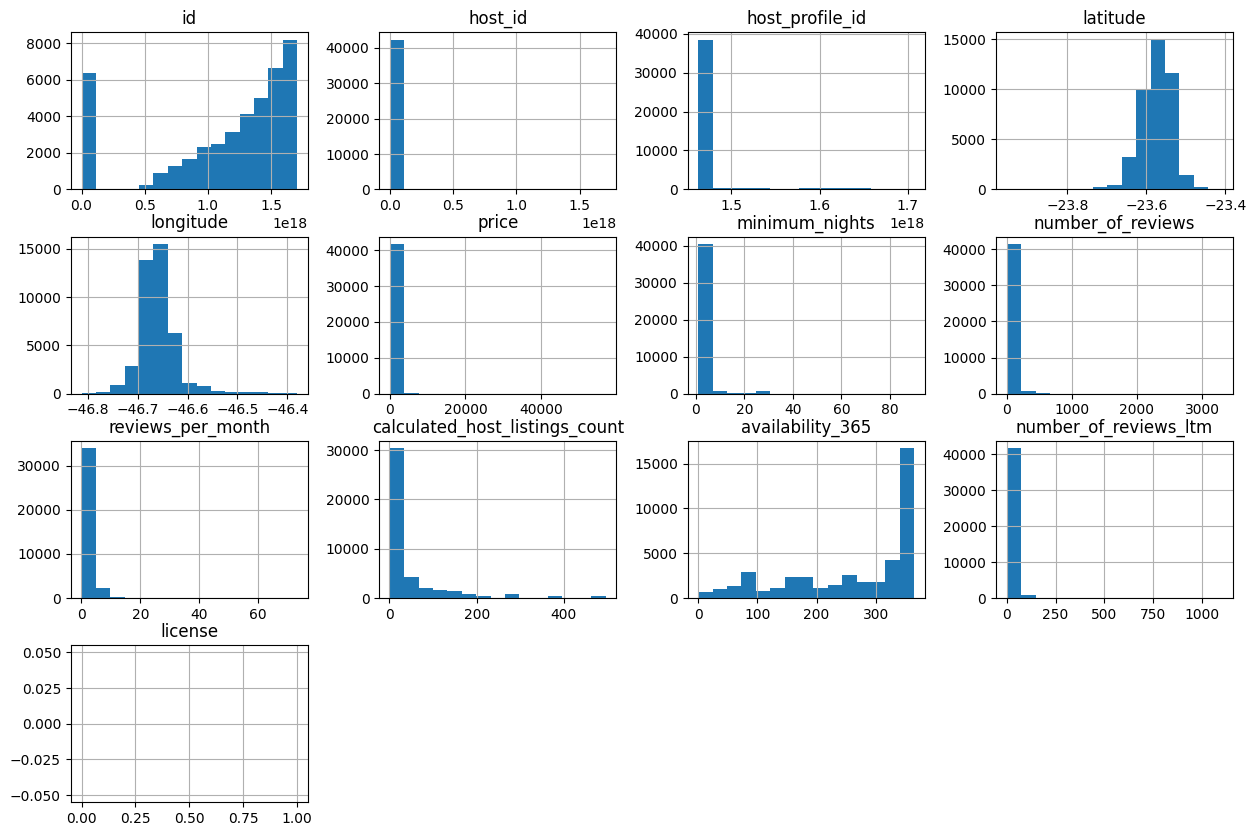

In [ ]:
# plotar o histograma das variáveis numéricas

df.hist(bins = 15, figsize = (15,10));


### **Q4. Há outliers presentes ?**

In [ ]:
df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,41852.000000,42367.000000,42378.000000,36604.00000,42363.000000,42378.000000
mean,418.201615,2.306819,37.224857,1.95565,42.449472,261.116499
std,817.634201,4.342603,66.693763,2.02786,82.838415,108.874811
min,12.000000,1.000000,0.000000,0.01000,1.000000,0.000000
25%,250.000000,1.000000,3.000000,0.60000,1.000000,173.000000
50%,331.000000,1.000000,14.000000,1.40000,6.000000,314.000000
75%,430.000000,2.000000,44.000000,2.70000,45.500000,356.000000
max,57127.000000,90.000000,3314.000000,73.21000,496.000000,365.000000


Olhando o resumo estatístico acima, podemos confirmar algumas hipóteses como:

- A variável `price` possui 75% dos valores abaixo de 430, porém o valor máximo é de 57127.



#### Boxplot para price

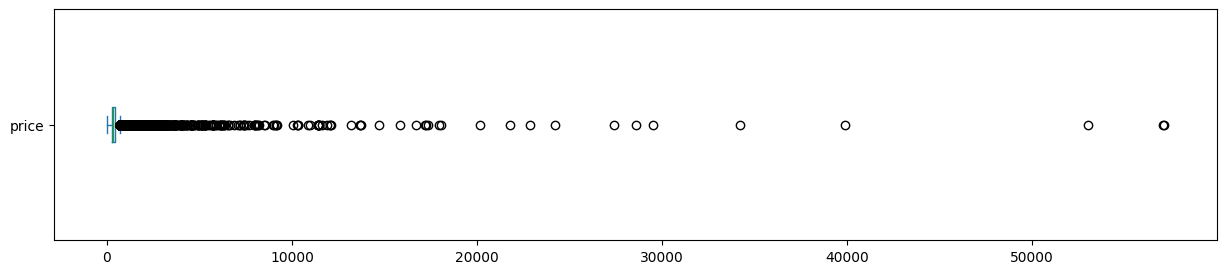

In [ ]:
df.price.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

In [ ]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr

print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Limite superior: {limite_superior}')

Q1: 250.0
Q3: 430.0
IQR: 180.0
Limite superior: 700.0


#### Boxplot para number_of_reviews

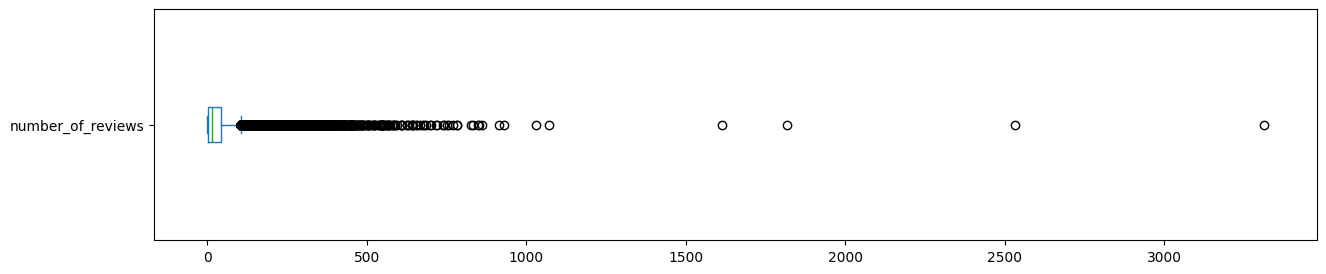

In [ ]:
df.number_of_reviews.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

In [ ]:
q1 = df['number_of_reviews'].quantile(0.25)
q3 = df['number_of_reviews'].quantile(0.75)

iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr

print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Limite superior: {limite_superior}')

Q1: 3.0
Q3: 44.0
IQR: 41.0
Limite superior: 105.5


#### Boxplot para reviews_per_month

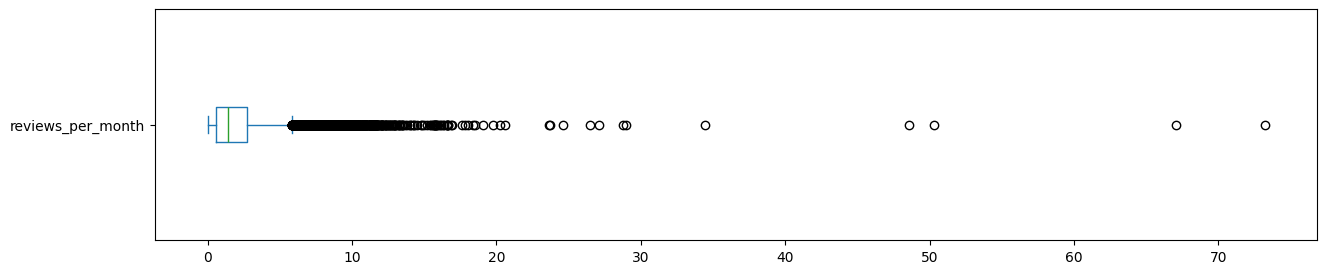

Q1: 0.6
Q3: 2.7
IQR: 2.1
Limite superior: 5.8500000000000005


In [ ]:
df.reviews_per_month.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

q1 = df['reviews_per_month'].quantile(0.25)
q3 = df['reviews_per_month'].quantile(0.75)

iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr

print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Limite superior: {limite_superior}')

Pela regra do intervalo interquartil (IQR), preços superiores a 700, bem como número de review acima de 105 e review por mês superior a 5.9 são considerados possíveis outliers estatísticos. Esses valores devem ser investigados para verificar se representam erros nos dados ou imóveis realmente mais caros, ou coisas parecidas.

#### Histogramas sem *outliers*

Já que identificamos *outliers* na variável `price`, vamos agora limpar o *DataFrame* delas e plotar novamente o histograma.

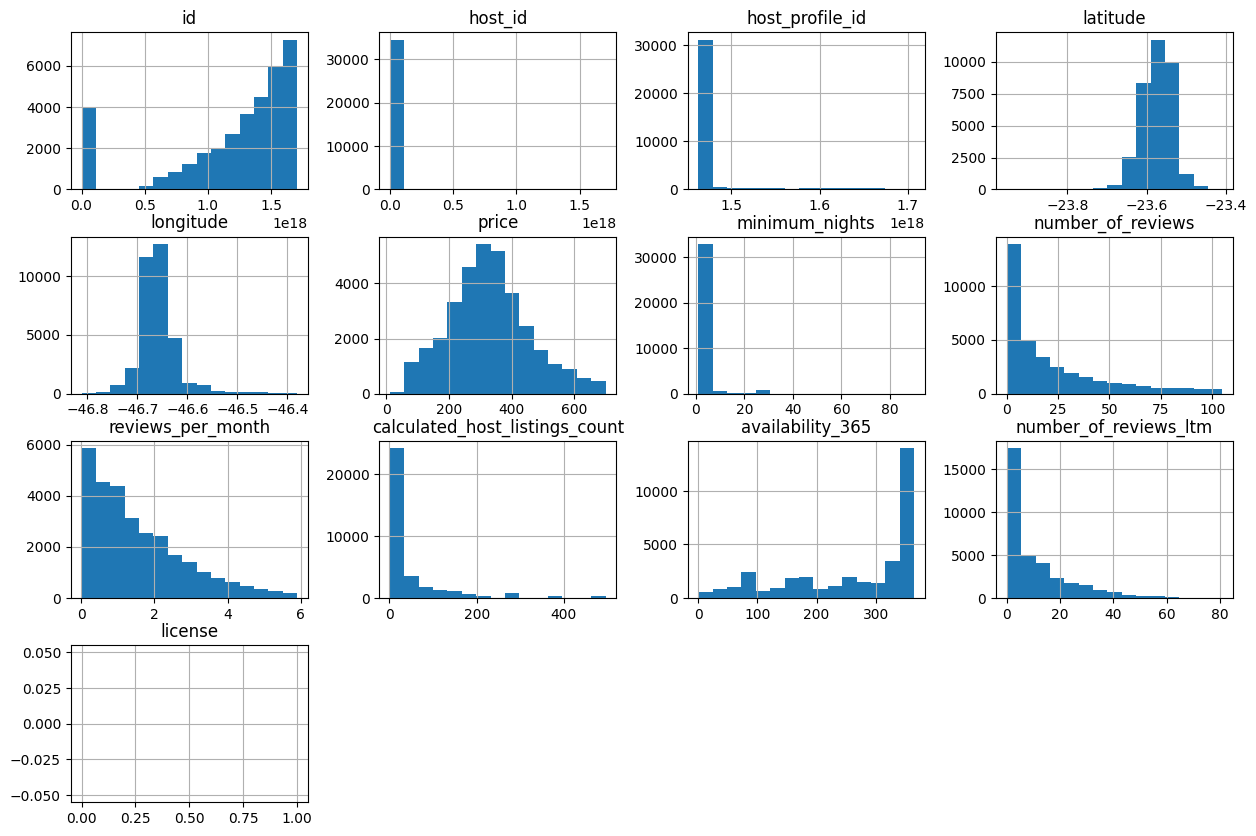

In [ ]:
df_clean = df.copy()
df_clean.drop(df_clean[df_clean.price > 700].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.number_of_reviews > 105.5].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.reviews_per_month > 5.9].index, axis=0, inplace=True)
df_clean.hist(bins=15, figsize=(15,10));



### **Q4. Qual a correlação existente entre as variáveis**

In [ ]:
# criar uma matriz de correlação
corr = df_clean[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].corr()


# mostrar a matriz de correlação
display(corr)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,-0.210402,-0.011019,0.012038,0.099755,0.000324
minimum_nights,-0.210402,1.000000,-0.098906,-0.202543,-0.084852,-0.015590
number_of_reviews,-0.011019,-0.098906,1.000000,0.439188,-0.058311,-0.119538
reviews_per_month,0.012038,-0.202543,0.439188,1.000000,0.006961,-0.025058
calculated_host_listings_count,0.099755,-0.084852,-0.058311,0.006961,1.000000,0.186520
availability_365,0.000324,-0.015590,-0.119538,-0.025058,0.186520,1.000000


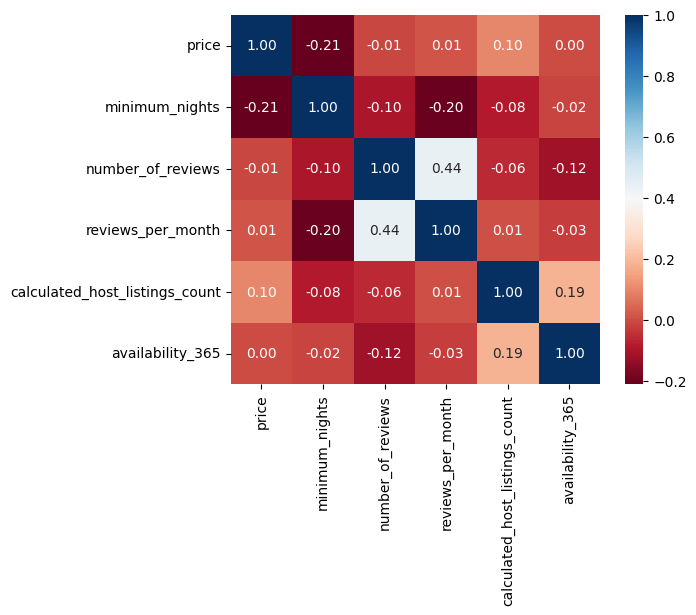

In [ ]:
# plotar um heatmap a partir das correlações
sns.heatmap(corr, cmap='RdBu', fmt='.2f', square=True, linecolor='white', annot=True);

### **Q5. Qual o tipo de imóvel mais alugado no Airbnb?**

In [ ]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_clean.room_type.value_counts()

,count
room_type,
Entire home/apt,29376
Private room,4914
Shared room,281
Hotel room,23


In [ ]:
# mostrar a porcentagem de cada tipo de imóvel disponível
df_clean.room_type.value_counts() / df_clean.shape[0]

,count
room_type,
Entire home/apt,0.849165
Private room,0.142048
Shared room,0.008123
Hotel room,0.000665


Aqui conseguimos estimar que 85% das locações totais do Airbnb são de casas ou apartamentos inteiros, seguido por 14% de quartos privados.

### **Q6. Qual a localidade mais cara do dataset?**



In [ ]:
# ver preços por bairros, na média
df.groupby('neighbourhood')['price'].mean().sort_values(ascending = False)[:10]

,price
neighbourhood,
Cidade Tiradentes,1214.666667
Morumbi,1099.510823
Marsilac,1089.421053
Grajau,926.280000
Parelheiros,921.274194
Vila Leopoldina,825.722222
Artur Alvim,818.205128
Jose Bonifacio,801.760000
Iguatemi,779.333333


Conseguimos ver em ordem decrescente quais os bairros possuem uma média de preço maior.

In [ ]:
# plotar os imóveis pela latitude-longitude
print(df[df.neighbourhood == "Vila Leopoldina"].shape)

df[df.neighbourhood == "Vila Leopoldina"]

(74, 19)


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
204,2371860,BOUTIQUE DUPLEX LOFT W/ GARAGE,2972985.0,1.462614e+18,Juliana,Lapa,Vila Leopoldina,-23.532410,-46.728980,Entire home/apt,246.0,2.0,44,2025-12-28,0.30,1.0,318,4,NaN
239,2573914,Great apartment in Vila Leopoldina wifi 200Mb,13179689.0,1.462585e+18,Hugo,Lapa,Vila Leopoldina,-23.518040,-46.728880,Entire home/apt,852.0,3.0,48,2024-08-29,0.45,7.0,336,0,NaN
335,3132099,APARTAMENTO Aconchegante - Vila Leopoldina,15904881.0,1.462973e+18,Debora,Lapa,Vila Leopoldina,-23.530780,-46.731320,Entire home/apt,3823.0,3.0,0,NaN,NaN,1.0,364,0,NaN
573,7227751,Charme Urbano,37842058.0,1.465566e+18,Beatriz,Lapa,Vila Leopoldina,-23.533100,-46.743480,Entire home/apt,515.0,30.0,20,2025-07-09,0.15,1.0,363,1,NaN
599,7673155,Condomínio/clube completo AP 130 m,40289577.0,1.465601e+18,Aide,Lapa,Vila Leopoldina,-23.520440,-46.724780,Entire home/apt,945.0,15.0,1,2016-04-11,0.01,1.0,134,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40034,1674467005979412084,Canto Primavera Leopoldina,194145171.0,1.469011e+18,Stephanie,Lapa,Vila Leopoldina,-23.526847,-46.732548,Entire home/apt,508.0,1.0,2,2026-06-11,2.00,13.0,321,2,NaN
41525,1695129680358310240,Estúdio na frente da universidade Cruzeiro do Sul,315122831.0,1.463441e+18,Lucivaldo,Lapa,Vila Leopoldina,-23.528630,-46.733270,Entire home/apt,286.0,2.0,1,2026-06-03,1.00,2.0,353,1,NaN
41574,1695918683983133336,Olive House Leopoldina,194145171.0,1.469011e+18,Stephanie,Lapa,Vila Leopoldina,-23.526400,-46.732530,Entire home/apt,508.0,1.0,4,2026-06-14,4.00,13.0,342,4,NaN
41955,1701511695252398518,Apê ao lado do Parque Villa Lobos,365968659.0,1.469737e+18,Fernanda,Lapa,Vila Leopoldina,-23.542430,-46.732150,Entire home/apt,250.0,1.0,0,NaN,NaN,2.0,34,0,NaN


df_clean

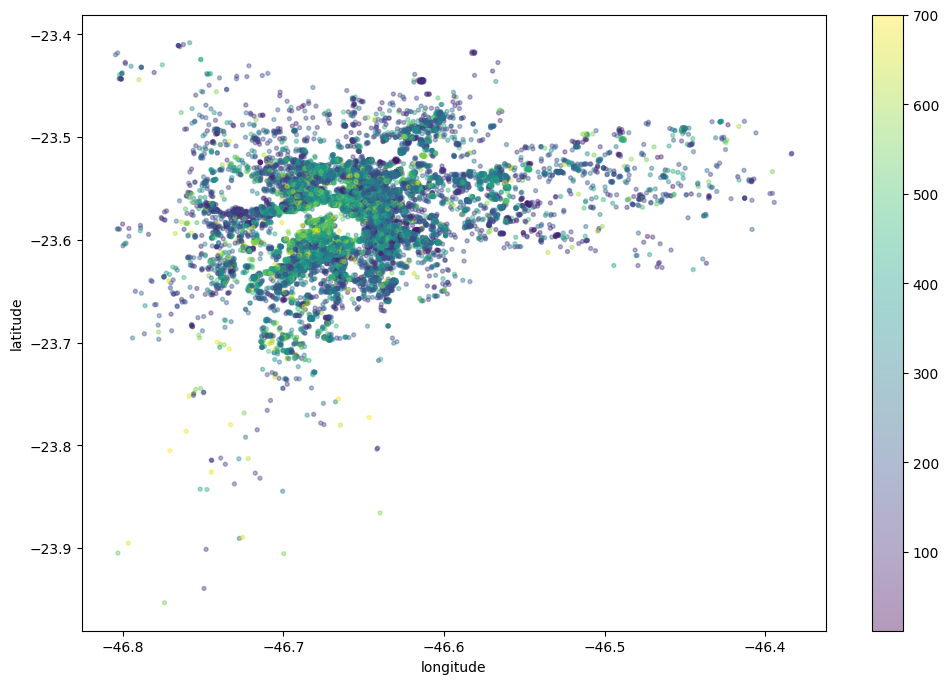

In [ ]:
df_clean.plot(kind="scatter", x='longitude', y='latitude', alpha=0.4, c=df_clean['price'], s=8,
              cmap=plt.get_cmap('viridis'), figsize=(12,8));

A partir do gráfico de dispersão, é possivel observar maior concentração de imóveis em determinadas regiões, enquanto outras possuem poucos registros. A maioria dos anúncios apresenta cores em tons azulados, indicando preços mais baixos ou intermediários, e os anúncios com preços mais elevados aparecem em menor quantidade e estão distribuídos pela cidade. Os pontos isolados devem ser investigados para verificar se correspondem a localizações reais ou possíveis inconsistências nas coordenadas.

### **Q7. Qual é a média do mínimo de noites para aluguel (minimum_nights)?**

In [ ]:
# ver a média da coluna `minimum_nights``

df.minimum_nights.mean()

np.float64(2.3068189864753226)

## Conclusões

Nesta análise exploratória inicial, foi possível conhecer melhor o conjunto de dados de anúncios do Airbnb em São Paulo. Foram analisadas a estrutura dos dados, as variáveis disponíveis, os valores ausentes, a distribuição dos preços, os tipos de acomodação, a quantidade de avaliações e a localização geográfica dos anúncios.

Observou-se que a maior parte dos anúncios corresponde a casas ou apartamentos inteiros. Os preços e a quantidade de avaliações não estão distribuídos de maneira uniforme, pois existem alguns valores muito altos em comparação com a maioria dos registros. Também foi possível observar que os anúncios estão concentrados em determinadas regiões de São Paulo.

Essa análise inicial ajudou a identificar padrões, possíveis valores extremos e informações que podem ser investigadas em análises futuras..